# 10 — Análisis por nivel y comparación global de modelos

Cuaderno para cruzar los resultados de la E3/E4 por nivel de dificultad, sin volver a entrenar nada. Solo cargamos fronteras, predicciones ya guardadas y métricas finales para comparar Word2Vec, TF-IDF y los prototipos con embeddings contextuales.

## 0. Setup
Importamos solo lo necesario, silenciamos warnings y fijamos rutas. Nada de GPU aquí, todo es lectura ligera.

In [3]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

LEVELS = ["easy", "medium", "hard"]
SEED = 42


def find_project_root(marker: str = '.git') -> Path:
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError('No se encontró la raíz del proyecto')


def boundaries_to_segments(y_boundaries: np.ndarray) -> np.ndarray:
    y_boundaries = np.asarray(y_boundaries, dtype=int)
    n_sentences = len(y_boundaries) + 1
    segments = np.zeros(n_sentences, dtype=int)
    current = 0
    segments[0] = current
    for i, val in enumerate(y_boundaries):
        if val:
            current += 1
        segments[i + 1] = current
    return segments


def pk(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    reference = np.asarray(reference)
    hypothesis = np.asarray(hypothesis)
    if reference.shape != hypothesis.shape:
        raise ValueError('reference y hypothesis deben tener la misma longitud')
    if k <= 0 or len(reference) <= k:
        return 0.0
    disagreements = 0
    total = 0
    for i in range(len(reference) - k):
        same_ref = reference[i] == reference[i + k]
        same_hyp = hypothesis[i] == hypothesis[i + k]
        disagreements += int(same_ref != same_hyp)
        total += 1
    return disagreements / total if total else 0.0


def windowdiff(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    reference = np.asarray(reference, dtype=int)
    hypothesis = np.asarray(hypothesis, dtype=int)
    if reference.shape != hypothesis.shape:
        raise ValueError('reference y hypothesis deben tener la misma longitud')
    n_sentences = len(reference) + 1
    if k <= 0 or n_sentences <= k:
        return 0.0
    total = n_sentences - k
    errors = 0
    for start in range(total):
        end = start + k - 1
        ref_count = reference[start:end].sum()
        hyp_count = hypothesis[start:end].sum()
        errors += int(ref_count != hyp_count)
    return errors / total if total else 0.0


def evaluate_predictions(df_boundaries: pd.DataFrame, y_pred: np.ndarray) -> dict:
    df = df_boundaries.sort_values(['level', 'doc_id', 'boundary_id']).reset_index(drop=True)
    y_true = df['y'].to_numpy().astype(int)
    y_pred = np.asarray(y_pred, dtype=int)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    doc_records = []
    seg_lengths = []
    for (_, _doc_id), group in df.groupby(['level', 'doc_id']):
        idx = group.index.to_numpy()
        y_doc = group['y'].to_numpy()
        doc_records.append((idx, y_doc))
        seg = boundaries_to_segments(y_doc)
        _, counts = np.unique(seg, return_counts=True)
        seg_lengths.extend(counts.tolist())
    mean_segment_length = float(np.mean(seg_lengths)) if seg_lengths else 1.0
    k = max(1, int(round(mean_segment_length / 2)))
    pk_scores = []
    wd_scores = []
    for idx, y_doc in doc_records:
        y_pred_doc = y_pred[idx]
        seg_true = boundaries_to_segments(y_doc)
        seg_pred = boundaries_to_segments(y_pred_doc)
        pk_scores.append(pk(seg_true, seg_pred, k=k))
        wd_scores.append(windowdiff(y_doc, y_pred_doc, k=k))
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'pk': float(np.mean(pk_scores)) if pk_scores else np.nan,
        'windowdiff': float(np.mean(wd_scores)) if wd_scores else np.nan,
        'k_window': k,
    }

PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
BOUNDARIES_DIR = DATA_PROCESSED / 'boundaries'
REPORTS_DIR = PROJECT_ROOT / 'reports'
PRED_DIR = DATA_PROCESSED / 'predictions'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PRED_DIR:', PRED_DIR)


PROJECT_ROOT: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis
PRED_DIR: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis/data/processed/predictions


## 1. Cargar datos de fronteras
Las tablas `boundaries_train.csv` y `boundaries_validation.csv` contienen una fila por frontera entre frases consecutivas con el `level`, `doc_id`, índices de las frases (`idx_left`, `idx_right`) y la etiqueta `y` (1 si hay cambio de autor).

In [4]:
df_train = pd.read_csv(BOUNDARIES_DIR / 'boundaries_train.csv')
df_val = pd.read_csv(BOUNDARIES_DIR / 'boundaries_validation.csv')
ORDER_COLS = ['level', 'doc_id', 'boundary_id']
df_val_sorted = df_val.sort_values(ORDER_COLS).reset_index(drop=True)
print(f"Train fronteras: {len(df_train):,} | pct cambio: {df_train['y'].mean():.3f}")
print(f"Val fronteras: {len(df_val):,} | pct cambio: {df_val['y'].mean():.3f}")
df_val_sorted.head()


Train fronteras: 159,002 | pct cambio: 0.191
Val fronteras: 33,858 | pct cambio: 0.194


,level,split,doc_id,boundary_id,sent_left_id,sent_right_id,idx_left,idx_right,y
0,easy,validation,problem-1,0,0,1,0,1,1
1,easy,validation,problem-1,1,1,2,1,2,1
2,easy,validation,problem-1,2,2,3,2,3,0
3,easy,validation,problem-1,3,3,4,3,4,0
4,easy,validation,problem-1,4,4,5,4,5,0


## 2. Cargar resultados de modelos
Cargamos las predicciones ya guardadas en `data/processed/predictions`. Para los modelos donde solo tenemos métricas agregadas (ej. `tfidf_svm` del Notebook 08) anotamos que no es posible recalcular por nivel.

In [5]:
results = {}
y_true_full = df_val_sorted['y'].to_numpy(dtype=int)
pred_files = {
    'w2v_logreg': PRED_DIR / 'w2v_logreg_val.npz',
    'w2v_svm': PRED_DIR / 'w2v_svm_val.npz',
    'w2v_mlp': PRED_DIR / 'w2v_mlp_val.npz',
    'bert_mlp': PRED_DIR / 'bert_mlp_val.npz',
    'bert_lstm': PRED_DIR / 'bert_lstm_val.npz',
    'bert_cnn': PRED_DIR / 'bert_cnn_val.npz',
}
for label, path in pred_files.items():
    if path.exists():
        data = np.load(path)
        results[label] = {
            'label': label,
            'split': 'validation',
            'y_true': data['y_true'],
            'y_pred': data['y_pred'],
        }
    else:
        print(f"No encontré {path}, no se podrá recalcular {label} por nivel.")

# Baselines sencillos directamente aquí
results['never_change'] = {
    'label': 'never_change',
    'split': 'validation',
    'y_true': y_true_full,
    'y_pred': np.zeros_like(y_true_full),
}
p_change = df_train['y'].mean()
_rng = np.random.default_rng(SEED)
results['random_p_train'] = {
    'label': 'random_p_train',
    'split': 'validation',
    'y_true': y_true_full,
    'y_pred': (_rng.random(len(y_true_full)) < p_change).astype(int),
}

# Métricas agregadas para tfidf_svm (sin predicciones)
metrics_only = {}
svm08_path = REPORTS_DIR / '08_svm_metrics.json'
if svm08_path.exists():
    metrics_only['tfidf_svm'] = json.loads(svm08_path.read_text())['metrics_val']
else:
    print('No encontré reports/08_svm_metrics.json, tfidf_svm quedará vacío.')

list(results.keys())


['w2v_logreg',
 'w2v_svm',
 'w2v_mlp',
 'bert_mlp',
 'bert_lstm',
 'bert_cnn',
 'never_change',
 'random_p_train']

## 3. Funciones de métricas
Reutilizamos las funciones ligeras de `accuracy`, `f1_macro`, `Pk` y `WindowDiff` que ya teníamos en los cuadernos 07 y 08. (Ver celda de setup).

## 4. Métricas por nivel
Para cada modelo con predicciones disponibles filtramos `df_val` por `level` (`easy`, `medium`, `hard`) y recalculamos las métricas. Los modelos sin predicciones quedan marcados en la tabla.

In [6]:
per_level_rows = []
global_metrics = {}
for label, payload in results.items():
    y_true = payload['y_true']
    y_pred = payload['y_pred']
    if len(y_true) != len(df_val_sorted):
        print(f"Longitudes distintas para {label}, se omite del análisis.")
        continue
    df_full = df_val_sorted.copy()
    global_metrics[label] = evaluate_predictions(df_full, y_pred)
    for level in LEVELS:
        mask = df_full['level'] == level
        if mask.sum() == 0:
            continue
        df_level = df_full.loc[mask].copy()
        metrics = evaluate_predictions(df_level, y_pred[mask.to_numpy()])
        per_level_rows.append({
            'label': label,
            'level': level,
            'accuracy': metrics['accuracy'],
            'f1': metrics['f1_macro'],
            'pk': metrics['pk'],
            'windowdiff': metrics['windowdiff'],
        })

per_level_df = pd.DataFrame(per_level_rows)
per_level_df


,label,level,accuracy,f1,pk,windowdiff
0,w2v_logreg,easy,0.618095,0.525863,0.512993,0.370326
1,w2v_logreg,medium,0.633989,0.548129,0.485410,0.363092
2,w2v_logreg,hard,0.638013,0.496816,0.523638,0.373630
3,w2v_svm,easy,0.628148,0.529583,0.509378,0.362463
4,w2v_svm,medium,0.641919,0.552535,0.476616,0.357832
5,w2v_svm,hard,0.655782,0.502609,0.507256,0.357738
6,w2v_mlp,easy,0.797580,0.471099,0.411798,0.231520
7,w2v_mlp,medium,0.820882,0.618475,0.352837,0.191254
8,w2v_mlp,hard,0.834589,0.459889,0.337679,0.203473
9,bert_mlp,easy,0.800508,0.496024,0.400496,0.227123


In [7]:
pivot_f1 = per_level_df.pivot(index='label', columns='level', values='f1')
pivot_pk = per_level_df.pivot(index='label', columns='level', values='pk')
print('F1 por nivel:')
display(pivot_f1)
print('Pk por nivel:')
display(pivot_pk)


F1 por nivel:


level,easy,hard,medium
label,,,
bert_cnn,0.799691,0.500085,0.718324
bert_lstm,0.758391,0.500162,0.718302
bert_mlp,0.496024,0.491128,0.622164
never_change,0.442364,0.455002,0.441976
random_p_train,0.505485,0.494628,0.508785
w2v_logreg,0.525863,0.496816,0.548129
w2v_mlp,0.471099,0.459889,0.618475
w2v_svm,0.529583,0.502609,0.552535


Pk por nivel:


level,easy,hard,medium
label,,,
bert_cnn,0.183824,0.340774,0.253211
bert_lstm,0.223788,0.332948,0.253281
bert_mlp,0.400496,0.331794,0.351335
never_change,0.418675,0.337833,0.444125
random_p_train,0.463852,0.446201,0.472432
w2v_logreg,0.512993,0.523638,0.485410
w2v_mlp,0.411798,0.337679,0.352837
w2v_svm,0.509378,0.507256,0.476616


## 5. Tabla final global
Combinamos métricas globales y por nivel en una sola tabla. Para `tfidf_svm` usamos las métricas guardadas en el Notebook 08 (sin desglose por nivel).

In [8]:
summary_rows = []
labels_order = [
    'never_change',
    'random_p_train',
    'tfidf_svm',
    'w2v_logreg',
    'w2v_svm',
    'w2v_mlp',
    'bert_mlp',
    'bert_lstm',
    'bert_cnn',
]
for label in labels_order:
    row = {'label': label}
    global_vals = global_metrics.get(label)
    if global_vals:
        row.update({
            'f1_global': global_vals['f1_macro'],
            'pk_global': global_vals['pk'],
        })
    elif label in metrics_only:
        row['f1_global'] = metrics_only[label]['f1_macro']
        row['pk_global'] = metrics_only[label]['pk']
    else:
        row['f1_global'] = np.nan
        row['pk_global'] = np.nan
    for level in LEVELS:
        level_slice = per_level_df[(per_level_df['label'] == label) & (per_level_df['level'] == level)]
        if not level_slice.empty:
            row[f'f1_{level}'] = level_slice['f1'].iloc[0]
            row[f'pk_{level}'] = level_slice['pk'].iloc[0]
        else:
            row[f'f1_{level}'] = np.nan
            row[f'pk_{level}'] = np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('f1_global', ascending=False)
summary_df


,label,f1_global,pk_global,f1_easy,pk_easy,f1_medium,pk_medium,f1_hard,pk_hard
8,bert_cnn,0.701017,0.259269,0.799691,0.183824,0.718324,0.253211,0.500085,0.340774
7,bert_lstm,0.685249,0.270006,0.758391,0.223788,0.718302,0.253281,0.500162,0.332948
6,bert_mlp,0.553238,0.361209,0.496024,0.400496,0.622164,0.351335,0.491128,0.331794
2,tfidf_svm,0.544605,0.432065,NaN,NaN,NaN,NaN,NaN,NaN
5,w2v_mlp,0.537728,0.367438,0.471099,0.411798,0.618475,0.352837,0.459889,0.337679
4,w2v_svm,0.532388,0.497750,0.529583,0.509378,0.552535,0.476616,0.502609,0.507256
3,w2v_logreg,0.527246,0.507347,0.525863,0.512993,0.548129,0.485410,0.496816,0.523638
1,random_p_train,0.503895,0.460828,0.505485,0.463852,0.508785,0.472432,0.494628,0.446201
0,never_change,0.446294,0.400211,0.442364,0.418675,0.441976,0.444125,0.455002,0.337833


## 6. Gráficos comparativos
Barplots ligeros para visualizar F1 y Pk por modelo/nivel. El radar queda como tarea opcional si necesitamos algo más vistoso.

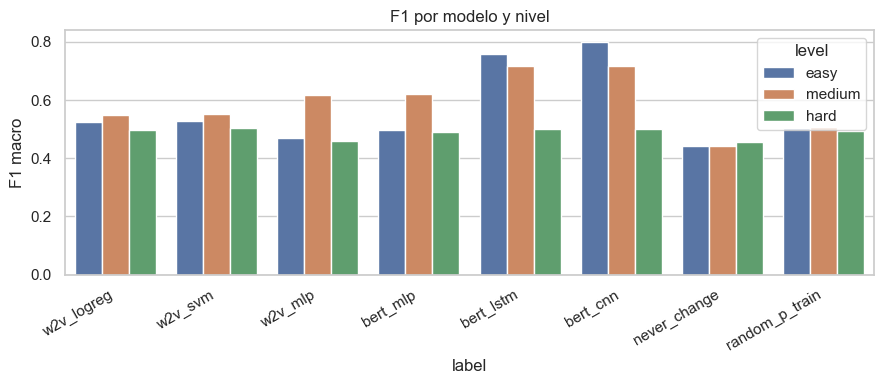

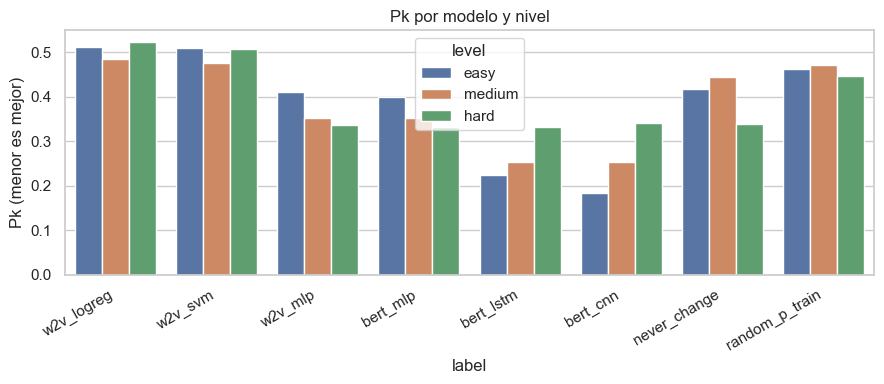

In [9]:
plt.figure(figsize=(9, 4))
sns.barplot(data=per_level_df, x='label', y='f1', hue='level')
plt.xticks(rotation=30, ha='right')
plt.ylabel('F1 macro')
plt.title('F1 por modelo y nivel')
plt.tight_layout()
plt.savefig(REPORTS_DIR / '10_f1_por_nivel.png', dpi=150)
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=per_level_df, x='label', y='pk', hue='level')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Pk (menor es mejor)')
plt.title('Pk por modelo y nivel')
plt.tight_layout()
plt.savefig(REPORTS_DIR / '10_pk_por_nivel.png', dpi=150)
plt.show()
